# FigSI HeLa Venn 3-sets
Yanbo Xu \
2026-06-24

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib_venn import venn3
from matplotlib.patches import Patch
from pathlib import Path

In [2]:
font_path = "/home/xuyanbo/ARIAL.TTF"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.size"] = 10
mpl.rcParams["figure.dpi"] = 300
mpl.rcParams["axes.linewidth"] = 0.8

In [3]:
BASE_TSV = Path("/home/xuyanbo/project/MOF_TAPS/analysis/fig_factory/fig/FigSI/hela_venn_3set/HeLa_gDNA.minTotal3.venn3.tsv")
FIG_DIR = Path("/home/xuyanbo/project/MOF_TAPS/analysis/fig_factory/fig/FigSI/hela_venn_3set")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
method_colors = {
    "MOF-TAPS": "#E59A2F",
    "TAPS+": "#3B82C4",
    "TAPS": "#63B34C",
}

region_colors = {
    "100": method_colors["MOF-TAPS"],
    "010": method_colors["TAPS+"],
    "001": method_colors["TAPS"],
    "110": "#D9D9D9",
    "101": "#D9D9D9",
    "011": "#D9D9D9",
    "111": "#EFEFEF",
}

def fmt_count(x):
    x = int(x)
    if x >= 1_000_000:
        s = f"{x / 1_000_000:.1f}M"
    elif x >= 1_000:
        s = f"{x / 1_000:.1f}K"
    else:
        s = str(x)
    return s.replace(".0M", "M").replace(".0K", "K")


In [5]:
def plot_venn3_from_row(row, ax):
    subsets = (
        int(row["A_only"]),
        int(row["B_only"]),
        int(row["AB_only"]),
        int(row["C_only"]),
        int(row["AC_only"]),
        int(row["BC_only"]),
        int(row["ABC"]),
    )

    v = venn3(
        subsets=subsets,
        set_labels=("", "", ""),
        ax=ax,
    )

    for region_id, color in region_colors.items():
        patch = v.get_patch_by_id(region_id)
        if patch is not None:
            patch.set_facecolor(color)
            patch.set_alpha(1.0)
            patch.set_edgecolor("none")

    region_values = {
        "100": row["A_only"],
        "010": row["B_only"],
        "110": row["AB_only"],
        "001": row["C_only"],
        "101": row["AC_only"],
        "011": row["BC_only"],
        "111": row["ABC"],
    }

    for region_id, value in region_values.items():
        label = v.get_label_by_id(region_id)
        if label is not None:
            label.set_text(fmt_count(value))
            label.set_color("black")
            label.set_fontsize(10)

    for label in v.set_labels:
        if label is not None:
            label.set_visible(False)

    ax.set_axis_off()
    return ax


In [6]:
venn_df = pd.read_csv(BASE_TSV, sep="	")
venn_df


,run_tag,comparison,k,set_A,set_B,set_C,A_only,B_only,C_only,AB_only,AC_only,BC_only,ABC,A_total,B_total,C_total,union
0,10pg,3way,minTotal3,MOF-TAPS,TAPS+,TAPS,1415584,391355,131771,42774,14799,4411,1915,1475072,440455,152896,2002609
1,100pg,3way,minTotal3,MOF-TAPS,TAPS+,TAPS,3684598,2038020,521256,7195110,1779303,899784,5696738,18355749,15829652,8897081,21814809
2,1ng,3way,minTotal3,MOF-TAPS,TAPS+,TAPS,688481,839490,439112,2475947,1458721,1998112,15432081,20055230,20745630,19328026,23331944


In [7]:
panel_order = [
    ("1ng", "1 ng"),
    ("100pg", "100 pg"),
    ("10pg", "10 pg"),
]

plot_df = pd.concat(
    [
        venn_df.loc[venn_df["run_tag"].eq(tag)].assign(panel_title=title)
        for tag, title in panel_order
    ],
    ignore_index=True,
)

plot_df


,run_tag,comparison,k,set_A,set_B,set_C,A_only,B_only,C_only,AB_only,AC_only,BC_only,ABC,A_total,B_total,C_total,union,panel_title
0,1ng,3way,minTotal3,MOF-TAPS,TAPS+,TAPS,688481,839490,439112,2475947,1458721,1998112,15432081,20055230,20745630,19328026,23331944,1 ng
1,100pg,3way,minTotal3,MOF-TAPS,TAPS+,TAPS,3684598,2038020,521256,7195110,1779303,899784,5696738,18355749,15829652,8897081,21814809,100 pg
2,10pg,3way,minTotal3,MOF-TAPS,TAPS+,TAPS,1415584,391355,131771,42774,14799,4411,1915,1475072,440455,152896,2002609,10 pg


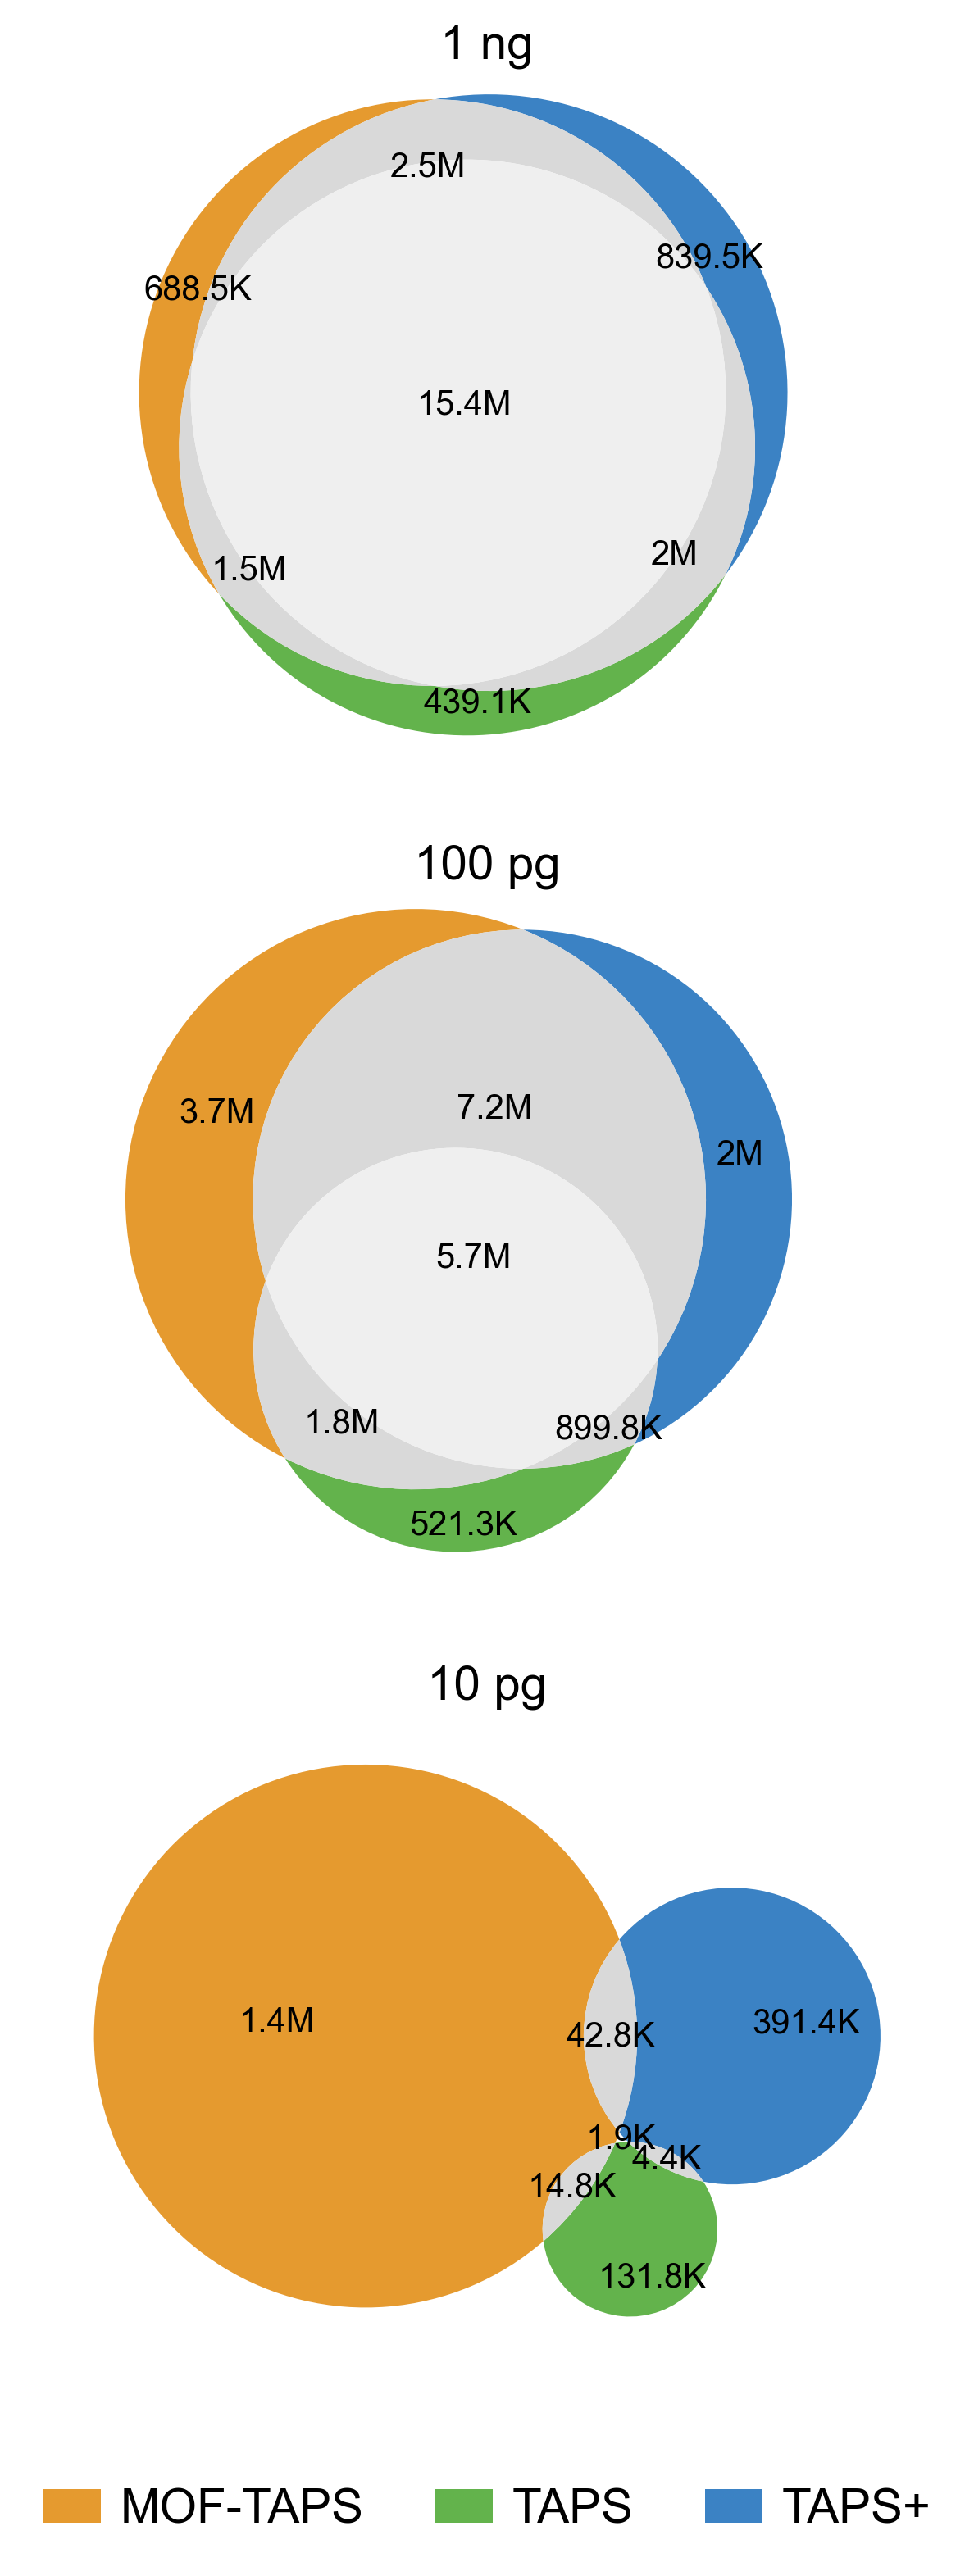

In [13]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(3, 1, figsize=(5.5, 11))

for ax, (_, row) in zip(axes, plot_df.iterrows()):
    plot_venn3_from_row(row, ax)
    ax.text(
        0.5, 0.95, row["panel_title"],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
    )

xmin = min(ax.get_xlim()[0] for ax in axes)
xmax = max(ax.get_xlim()[1] for ax in axes)
ymin = min(ax.get_ylim()[0] for ax in axes)
ymax = max(ax.get_ylim()[1] for ax in axes)

xpad = 0.06 * (xmax - xmin)
ypad = 0.06 * (ymax - ymin)

for ax in axes:
    ax.set_xlim(xmin + xpad, xmax - xpad)
    ax.set_ylim(ymin + ypad, ymax)
    ax.set_aspect("equal")

legend_handles = [
    Patch(facecolor=method_colors["MOF-TAPS"], edgecolor="none", label="MOF-TAPS"),
    Patch(facecolor=method_colors["TAPS"], edgecolor="none", label="TAPS"),
    Patch(facecolor=method_colors["TAPS+"], edgecolor="none", label="TAPS+"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=3,
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    columnspacing=1.5,
    fontsize=14,
)

fig.subplots_adjust(
    left=0.08,
    right=0.92,
    top=0.98,
    bottom=0.11,
    hspace=0.15
)

plt.savefig(
    f"{FIG_DIR}/combined_3way_venn_2.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05,
)
plt.show()